<a href="https://colab.research.google.com/github/ashorinajufan/KUMPULAN-TUGAS-DATA-MINING-/blob/main/DATA_KLASIFIKASI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#pemanggilan data
df = pd.read_csv('Iris.csv')

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# DATA PREPOCESSING

1. Cek data

Untuk memastikan tidak ada nilai yang kosong.

In [8]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


Menggunakan scatter plot untuk melihat hubungan antar fitur.

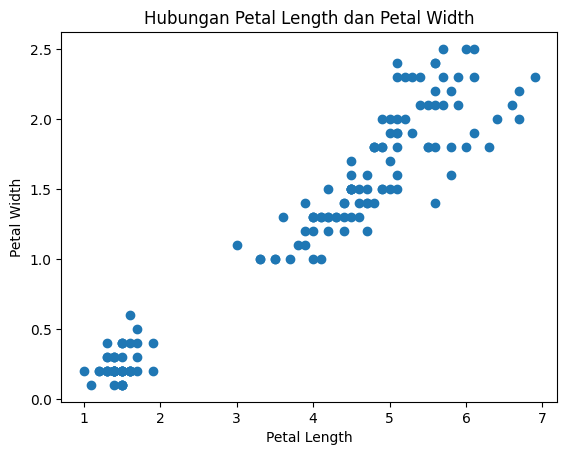

In [16]:
plt.figure()
plt.scatter(df['PetalLengthCm'], df['PetalWidthCm'])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Hubungan Petal Length dan Petal Width")
plt.show()

2. Pisahkan fitur dan targer

Data dipisahkan menjadi fitur (variabel independen) dan target (variabel dependen), di mana fitur berisi ukuran bunga dan target berisi jenis bunga.

In [9]:
X = df.drop(['Species', 'Id'], axis=1)
y = df['Species']

3. Encoding Target

Karena target masih berbentuk teks, dilakukan proses encoding untuk mengubahnya menjadi bentuk numerik.

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

4. Split Data

Data dibagi menjadi data latih dan data uji agar model dapat dilatih dan kemudian diuji performanya secara objektif.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# PEMBUAT MODEL

1. K-Nearest Neighbor (KNN)

Model K-Nearest Neighbor (KNN) dibangun dengan memanfaatkan konsep kedekatan antar data. Model ini bekerja dengan cara mencari sejumlah tetangga terdekat dari suatu data berdasarkan jarak, kemudian menentukan kelas berdasarkan mayoritas tetangga tersebut. KNN dipilih karena sederhana dan efektif untuk dataset yang memiliki pola pengelompokan yang jelas, seperti pada data Iris.

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

2. Decision Tree

Model Decision Tree dibuat dengan membangun struktur pohon keputusan berdasarkan fitur-fitur yang ada dalam dataset. Model ini bekerja dengan membagi data secara bertahap menggunakan aturan tertentu hingga setiap data masuk ke dalam kelas yang sesuai. Decision Tree memiliki keunggulan dalam hal interpretasi karena proses pengambilan keputusannya dapat ditelusuri dengan jelas melalui struktur pohon.

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# EVALUASI MODEL

1. Akurasi

Akurasi, yaitu perbandingan antara jumlah prediksi yang benar dengan total data

In [14]:
from sklearn.metrics import accuracy_score

acc_knn = accuracy_score(y_test, y_pred_knn)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Akurasi KNN:", acc_knn)
print("Akurasi Decision Tree:", acc_dt)

Akurasi KNN: 1.0
Akurasi Decision Tree: 1.0


2. Confusion Matrix

*Confusion matrix* untuk melihat distribusi kesalahan prediksi serta classification report untuk mengetahui nilai precision, recall, dan f1-score.

In [18]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_dt))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [19]:
from sklearn.metrics import classification_report
print("KNN Report")
print(classification_report(y_test, y_pred_knn))

print("DT Report")
print(classification_report(y_test, y_pred_dt))

KNN Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

DT Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

